In [1]:
import substrate_depletion_model as sd
import dimensionless as dim
import utils as u

import numpy as np
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt

To perform dimensional analysis on the system, substitute

$$
\begin{align}
    x &= \sqrt{\frac{D_s}{k_\text{off}}}\tilde{x}, &
    t &= \frac{\tilde{t}}{k_{\text{off}}}, &
    S &= S_0 \tilde{s}, &
    P &= S_0 \tilde{p} &
\end{align}
$$
where $L$ is the system length, into the PDEs to be reduced to:


\begin{equation}
\frac{\partial \tilde{s}}{\partial \tilde{t}} = \frac{\partial^2 \tilde{s}}{\partial \tilde{x}^2} + \frac{k_{\text{on}}}{k_\text{off}} \tilde{p}f(\tilde{s}) - \tilde{s}
\end{equation}

\begin{equation}
\frac{\partial \tilde{p}}{\partial \tilde{t}} = \frac{D_p}{D_s} \frac{\partial^2 \tilde{p}}{\partial \tilde{x}^2} - \frac{k_{\text{on}}}{k_\text{off}} \tilde{p} f(\tilde{s}) + \tilde{s}
\end{equation}


where 

$$
\begin{equation}
\frac{c}{S_0}\sqrt \frac{D_0}{D_s} = \int \tilde{p} + \tilde{s}  d\tilde{x}
\end{equation}
$$

where we substitute the concentration of molecules in the system, $c$, i.e., $c = N/L$ and $ D_0 = k_{\text{off}}L^2 $.

Also note that 

$$
\begin{equation}
f(\tilde{s}) = \frac{\tilde{s}^n}{1+\tilde{s}^n}
\end{equation}
$$

$$
\begin{align}
    d &= \frac{D_p}{D_s}, &
    k &= \frac{k_{\text{on}}}{k_\text{off}}, &
    S &= s_0 \tilde{s}, &
    P &= s_0 \tilde{p}, &
\end{align}
$$


### Non-dimensionalization for Substrate-depletion model
(Check Overleaf doc for details)

By non-dimensionalization of the substrate-depletion model, the system can be scaled to obtain the same dynamics.

First note the time scale,
$$ t_c \sim 1/k_{\text{off}}. $$

If we keep some length scale, $L$ constant, the diffusion coefficents scales as $$ D \sim k_{\text{off}}L^2. $$ 

Hence, let $D_0 = k_{\text{off}}L^2$, then we can write the dimensionless term for substrate concentration $\sqrt{\frac{D_0}{D_S}}$.

Concentration scales by scaling average concentration $ c = \frac{N}{L}$ over domain and parameter $ S_0 $ in $ f(S) $. If $ \frac{c}{S_0} $ is constant, profile is the same

Other parameters:

- Ratio of association to dissociation: $$ \frac{k_\text{on}}{k_\text{off}} = 20. $$

- Ratio of substrate to pool diffusion coefficient $$ \frac{D_s}{D_p} = 0.05. $$

Keeping these constant, the solution will have the same profile.

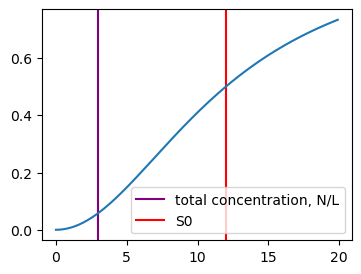

In [2]:
### visualize f sigmoid function
conc_to_S0 = 4
total_conc = 3
S0 = conc_to_S0 * total_conc
S = np.arange(0, 20, 0.1)
plt.figure(figsize=(4,3))
plt.axvline(total_conc, label="total concentration, N/L", color="Purple")
plt.axvline(S0, label="S0", color="Red")
plt.plot(S, sd.f(S, n=2, S0=S0))
plt.legend()

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1030.09it/s]


Text(0.5, 0, '$\\frac{N}{LS_0}$')

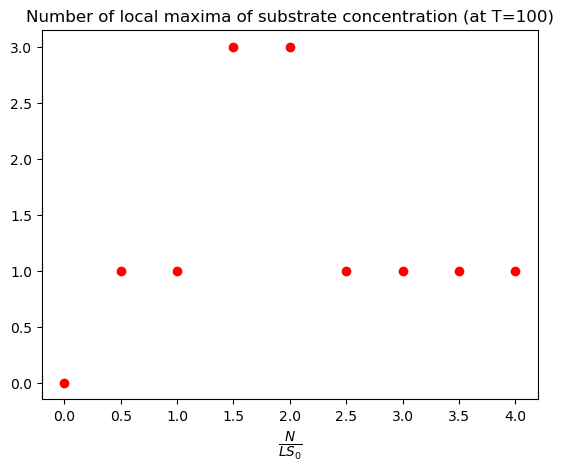

In [8]:
# concentration/S0 experiments
k_ratio = 20
D_ratio = 0.05
k_off = 1
Dk = 50
T = 100
dt = 0.1
dx = 0.05
average_conc = 3
L = 10

# varied parameter
S0_to_conc = np.arange(0, 4.5, 0.5)

npeak, Sc, order = dim.concentration_scale(S0_to_conc,
                                           L=L, 
                                           avg_conc=average_conc,
                                           k_off=k_off, 
                                           k_ratio=k_ratio,
                                           Dk=Dk,
                                           D_ratio=D_ratio,
                                           Tfinal=T,
                                           dt=dt,
                                           dx=dx,
                                           n=2)
fig, ax = plt.subplots()
ax.scatter(conc_to_S0, npeak, color="Red", label=f"T={T}")
ax.set_title(f"Number of local maxima of substrate concentration (at T={T})")
ax.set_xlabel(r"$\frac{N}{LS_0}$", fontsize=14)

In [2]:
# params for length scale experiment
k_ratio = 20
D_ratio = 0.05
T = 100
dt = 0.1
dx = 0.05
average_conc = 3
S0 = 6

L = 10
k_off = 1
# varied parameter
Dk = np.arange(10, 100, 5) # sqrt(D0/DS)

npeak_D = dim.length_scale(Dk, 
                           L=L, 
                           k_off=k_off, 
                           k_ratio=k_ratio,
                           D_ratio=D_ratio,
                           Tfinal=T,
                           dt=dt,
                           dx=dx,
                           n=2,
                           avg_conc = average_conc,
                           S0=S0)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1669.20it/s]


Text(0.5, 0, '$\\sqrt{\\frac{D_0}{D_S}}$')

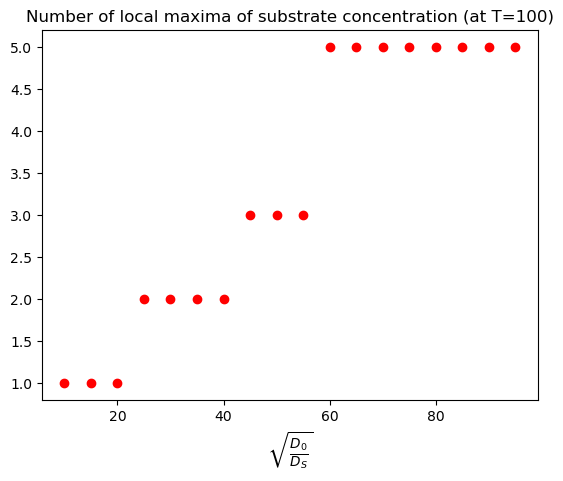

In [3]:
fig, ax = plt.subplots()
ax.scatter(Dk, npeak_D, color="Red", label=f"T={T}")
ax.set_title(f"Number of local maxima of substrate concentration (at T={T})")
ax.set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=14)
# ax.legend()

In [4]:
# params for association-dissociation ratio experiment
L = 10
dx = 0.05
T = 100
dt = 0.1
Dk = 50
D_ratio = 0.05
average_conc = 3
S0 = 6 

# varied parameter
k_ratio = np.arange(10, 32, 2) # k_on/k_off
k_off = 1

npeak_k, Spropfinal = dim.association_dissociation_scale(k_ratio, 
                                                         k_off=k_off,
                                                         L=L,
                                                         Dk=Dk,
                                                         D_ratio=D_ratio,
                                                         Tfinal=T,
                                                         dt=dt,
                                                         dx=dx,
                                                         n=2,
                                                         avg_conc=average_conc,
                                                         S0=S0)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1744.17it/s]


Text(0.5, 0, '$\\frac{k_{on}}{k_{off}}$')

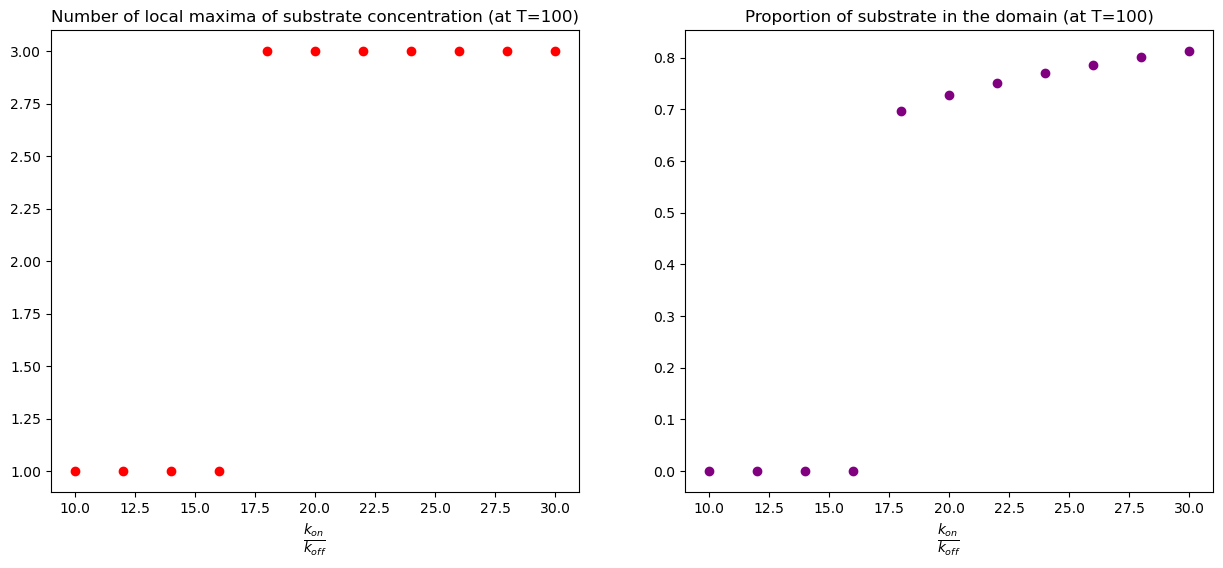

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].set_title(f"Number of local maxima of substrate concentration (at T={T})")
ax[0].scatter(k_ratio, npeak_k, color="Red")
ax[0].set_xlabel(r"$\frac{k_{on}}{k_{off}}$", fontsize=14)

ax[1].set_title(f"Proportion of substrate in the domain (at T={T})")
ax[1].scatter(k_ratio, Spropfinal, color="Purple")
ax[1].set_xlabel(r"$\frac{k_{on}}{k_{off}}$", fontsize=14)

In [71]:
# params for diffusion coefficients ratio experiment
L = 10
dx = 0.05
T = 100
dt = 0.1
k_ratio = 20
k_off = 1
average_conc = 3
S0 = 6 
Dk = 50
Ds = (L**2)*k_off/(Dk**2)
print(f"Diffusion coefficient of substrate is {Ds}.")

# varied parameter
D_ratio = np.linspace(0.01, 0.5, 10) # Dp/Ds

npeak_D, Spropfinal = dim.diffusion_coefficient_scale(D_ratio,
                                                      Dk=Dk,
                                                      L=L,
                                                      k_ratio=k_ratio,
                                                      k_off=k_off,
                                                      Tfinal=T,
                                                      dt=dt,
                                                      dx=dx,
                                                      n=2,
                                                      avg_conc=average_conc,
                                                      S0=S0)

Diffusion coefficient of substrate is 0.04.


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1234.00it/s]


Text(0.5, 0, '$\\frac{D_s}{D_p}$')

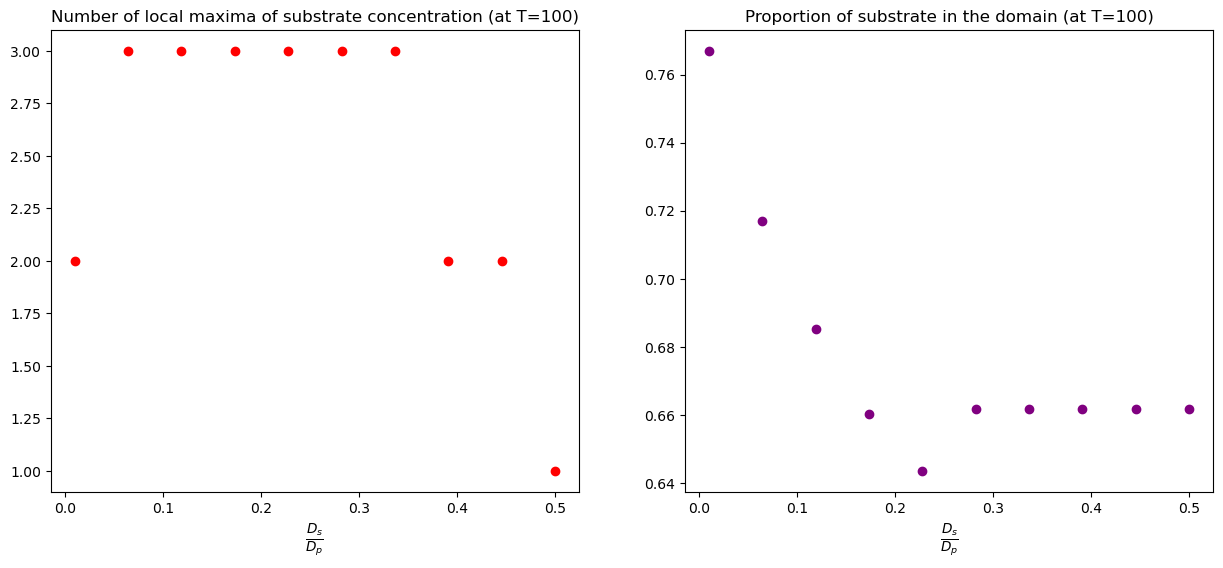

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].set_title(f"Number of local maxima of substrate concentration (at T={T})")
ax[0].scatter(D_ratio, npeak_D, color="Red")
ax[0].set_xlabel(r"$\frac{D_s}{D_p}$", fontsize=14)

ax[1].set_title(f"Proportion of substrate in the domain (at T={T})")
ax[1].scatter(D_ratio, Spropfinal, color="Purple")
ax[1].set_xlabel(r"$\frac{D_s}{D_p}$", fontsize=14)

### Dimensionless parameters analysis 

Analysing effects of dimensionless parameters on the system, i.e.,
the diffusion ratio $D_s/D_p$ and association-dissociation rate ratio $k_{\text{on}}/k_{\text{off}}$, vs the length scale dimensionless param $\sqrt{D_0/D_s}$, where $D_0 = L^2k_{\text{off}}$. 

Plots: 
- Scatter plot, color of dots are number of peaks
- Heat map of order parameter (normalized), i.e. $\int_0^L |dS/dx|$ 
- Heat map of final substrate concentration, $\int_0^L S(x,t) dx$

In [2]:
FOLDER = "parameter_results"
filenames = os.listdir(FOLDER)
print(filenames)
    
def load_results(filename, folder=FOLDER):
    # number of peaks
    with open(f"{FOLDER}/{filename}.npy", "rb") as file:
        npeak = np.load(file, allow_pickle=True)

    # final concentration of substrate
    with open(f"{FOLDER}/{filename}_Sconc.npy", "rb") as file:
        Sconc = np.load(file, allow_pickle=True)

    # order parameter (sum of absolute gradients)
    with open(f"{FOLDER}/{filename}_order.npy", "rb") as file:
        order = np.load(file, allow_pickle=True)
    
    return npeak, Sconc, order

['D_ratio_wider_vs_Dk_T100_order.npy', 'D_ratio_wider_vs_Dk_T300.npy', 'D_ratio_wider_vs_Dk_T100.npy', 'D_ratio_wider_vs_Dk_T100_Sconc.npy', 'k_ratio_vs_Dk_T300.npy', 'S0_to_conc_vs_Dk_T300_order.npy', 'D_ratio_vs_Dk_Sconc.npy', 'k_ratio_vs_Dk_T100_order.npy', 'k_ratio_vs_Dk_T100.npy', 'S0_to_conc_zoom_vs_Dk_T300_order.npy', 'S0_to_conc_zoom_vs_Dk_T300_Sconc.npy', 'k_ratio_vs_Dk_T100_Sconc.npy', 'S0_to_conc_vs_Dk_T300_Sconc.npy', 'S0_to_conc_vs_Dk_T100_order.npy', 'S0_to_conc_zoom_vs_Dk_T100.npy', 'S0_to_conc_zoom_vs_Dk_T300.npy', 'S0_to_conc_zoom_vs_Dk_T100_order.npy', 'k_ratio_vs_Dk_T300_order.npy', 'k_ratio_vs_Dk_Sconc.npy', 'D_ratio_vs_Dk.npy', 'k_ratio_vs_Dk_T300_Sconc.npy', 'S0_to_conc_zoom_vs_Dk_T100_Sconc.npy', 'S0_to_conc_vs_Dk_T100_Sconc.npy', 'k_ratio_vs_Dk.npy', 'S0_to_conc_vs_Dk_T300.npy', 'D_ratio_wider_vs_Dk_T300_order.npy', 'S0_to_conc_vs_Dk_T100.npy', 'D_ratio_wider_vs_Dk_T300_Sconc.npy']


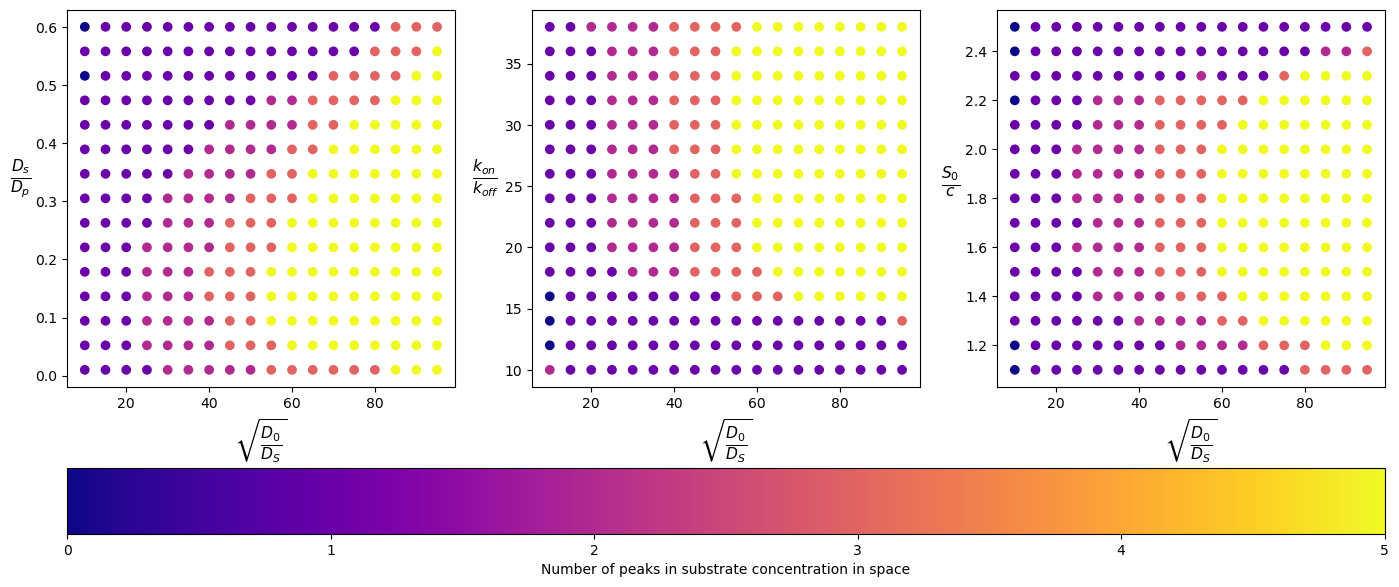

In [54]:
Dpeaks100, DS100, Dorder100 = load_results("D_ratio_wider_vs_Dk_T100")
kpeaks100, kS100, korder100 = load_results("k_ratio_vs_Dk_T100")
cS0peaks100, cS0S100, cS0order100 = load_results("S0_to_conc_zoom_vs_Dk_T100")

Dk = np.arange(10, 100, 5) # sqrt(D0/DS)

fig, ax = plt.subplots(1, 3, figsize=(17, 7))

Dratio = np.linspace(0.01, 0.6, 15)
for i in range(len(Dk)):
    im1 = ax[0].scatter(np.ones_like(Dratio)*Dk[i], 
                   Dratio, 
                   c=Dpeaks100[:, i], 
                   cmap="plasma", 
                   vmin=0, 
                   vmax=5)
ax[0].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
ax[0].set_ylabel(r"$\frac{D_s}{D_p}$", fontsize=16, rotation=360)
ax[0].yaxis.set_label_coords(-0.12,0.5)
    
k_ratio = np.arange(10, 40, 2) # kon/koff
for i in range(len(Dk)):
    ax[1].scatter(np.ones_like(k_ratio)*Dk[i], 
                   k_ratio, 
                   c=kpeaks100[:, i], 
                   cmap="plasma", 
                   vmin=0, 
                   vmax=5)
ax[1].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
ax[1].set_ylabel(r"$\frac{k_{on}}{k_{off}}$", fontsize=16, rotation=360)
ax[1].yaxis.set_label_coords(-0.12,0.5)

S0_to_conc = np.arange(1.1, 2.6, 0.1) # S0/(N/L)
for i in range(len(Dk)):
    ax[2].scatter(np.ones_like(S0_to_conc)*Dk[i], 
                   S0_to_conc, 
                   c=cS0peaks100[:, i], 
                   cmap="plasma", 
                   vmin=0, 
                   vmax=5)
ax[2].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
ax[2].set_ylabel(r"$\frac{S_0}{c}$", fontsize=16, rotation=360)
ax[2].yaxis.set_label_coords(-0.12,0.5)
    
fig.colorbar(im1, 
             ax=[ax[0], ax[1], ax[2]], 
             orientation="horizontal",
             label="Number of peaks in substrate concentration in space",
             shrink=0.7)    

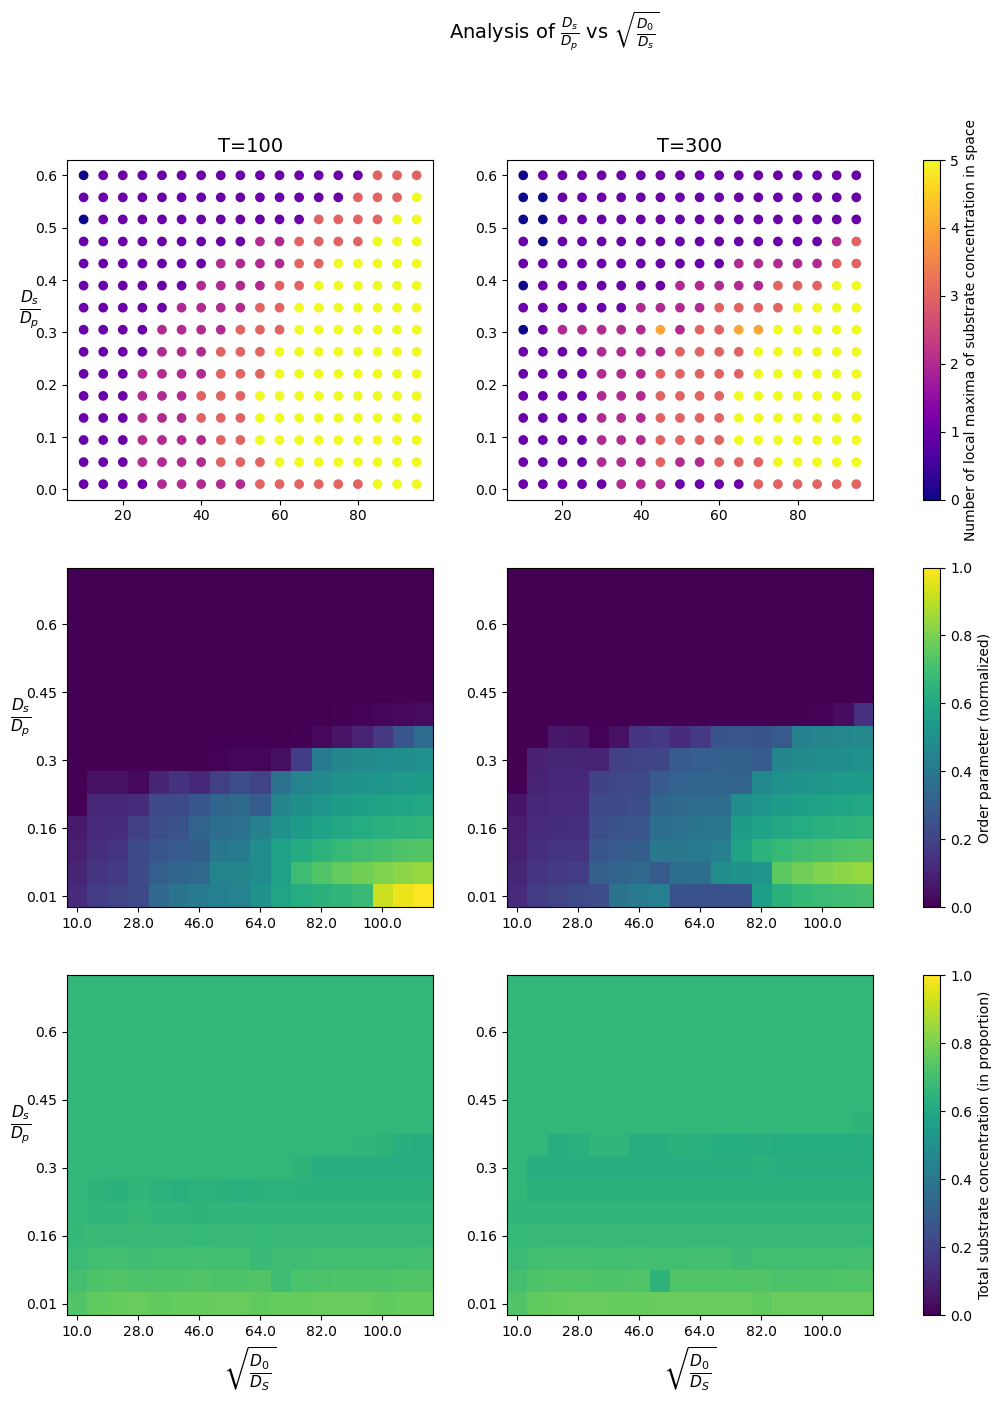

In [15]:
# D_ratio for T=100 and 300
Dpeaks100, DS100, Dorder100 = load_results("D_ratio_wider_vs_Dk_T100")
Dpeaks300, DS300, Dorder300 = load_results("D_ratio_wider_vs_Dk_T300")
Dratio = np.linspace(0.01, 0.6, 15) # Ds/Dp

def plot_data(Dpeaks100, 
              DS100, 
              Dorder100, 
              Dpeaks300, 
              DS300, 
              Dorder300, 
              D_ratio=Dratio, 
              ylabel=r"$\frac{D_s}{D_p}$"):
    
    norm = np.nanmax((Dorder100, Dorder300))
    Dorder100 = Dorder100/norm
    Dorder300 = Dorder300/norm

    # set up parameters
    Dk = np.arange(10, 100, 5) # sqrt(D0/DS)

    row = 3
    col = 2
    fig, ax = plt.subplots(row, col, figsize=(13, 15))
    D0Ds = r"$\sqrt{\frac{D_0}{D_s}}$"
    fig.suptitle(f"Analysis of {ylabel} vs {D0Ds}",
                 fontsize=14)

    # plot npeak scatter plot
    for i in range(len(Dk)):
        im1 = ax[0][0].scatter(np.ones_like(D_ratio)*Dk[i], 
                               D_ratio, 
                               c=Dpeaks100[:, i], 
                               cmap="plasma", 
                               vmin=0, 
                               vmax=5)
        im2 = ax[0][1].scatter(np.ones_like(D_ratio)*Dk[i], 
                               D_ratio, 
                               c=Dpeaks300[:, i], 
                               cmap="plasma", 
                               vmin=0, 
                               vmax=5)
    fig.colorbar(im2, 
                 ax=[ax[0][0], ax[0][1]], 
                 orientation="vertical",
                 label="Number of local maxima of substrate concentration in space")    

    # plot heatmap of order param
    tickx = np.arange(0, len(Dk), 3)
    Dk_label = np.linspace(10, 100, len(tickx)).tolist()
    
    ticky = np.arange(0, len(D_ratio), 3)
    Dratio_label = np.around(np.linspace(D_ratio[0], D_ratio[-1], len(ticky)), 2).tolist()
    
    im3 = ax[1][0].imshow(Dorder100,
                          origin="lower",
                          vmin=0,
                          vmax=1,
                          aspect="auto")
    ax[1][0].set_xticks(tickx)
    ax[1][0].set_xticklabels(Dk_label)
    ax[1][0].set_yticks(ticky)
    ax[1][0].set_yticklabels(Dratio_label)

    im4 = ax[1][1].imshow(Dorder300,
                          origin="lower",
                          vmin=0,
                          vmax=1,
                          aspect="auto")
    ax[1][1].set_xticks(tickx)
    ax[1][1].set_xticklabels(Dk_label)
    ax[1][1].set_yticks(ticky)
    ax[1][1].set_yticklabels(Dratio_label)
    fig.colorbar(im4, 
                 ax=[ax[1][0], ax[1][1]],
                 orientation="vertical",
                 label="Order parameter (normalized)")


    # plot heatmap of S concentration
    im5 = ax[2][0].imshow(DS100,
                          origin="lower",
                          vmin=0,
                          vmax=1,
                          aspect="auto")
    ax[2][0].set_xticks(tickx)
    ax[2][0].set_xticklabels(Dk_label)
    ax[2][0].set_yticks(ticky)
    ax[2][0].set_yticklabels(Dratio_label)

    im6 = ax[2][1].imshow(DS300,
                          origin="lower",
                          vmin=0,
                          vmax=1,
                          aspect="auto")
    ax[2][1].set_xticks(tickx)
    ax[2][1].set_xticklabels(Dk_label)
    ax[2][1].set_yticks(ticky)
    ax[2][1].set_yticklabels(Dratio_label)
    fig.colorbar(im6, 
                 ax=[ax[2][0], ax[2][1]],
                 orientation="vertical",
                 label="Total substrate concentration (in proportion)")

    # set labels
    ax[0][0].set_title("T=100", fontsize=14)
    ax[0][1].set_title("T=300", fontsize=14)
    for j in range(col):
        ax[2][j].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
    for i in range(row):
        ax[i][0].set_ylabel(ylabel, fontsize=16, rotation=0)
    
    plt.show()
plot_data(Dpeaks100, DS100, Dorder100, Dpeaks300, DS300, Dorder300)
             

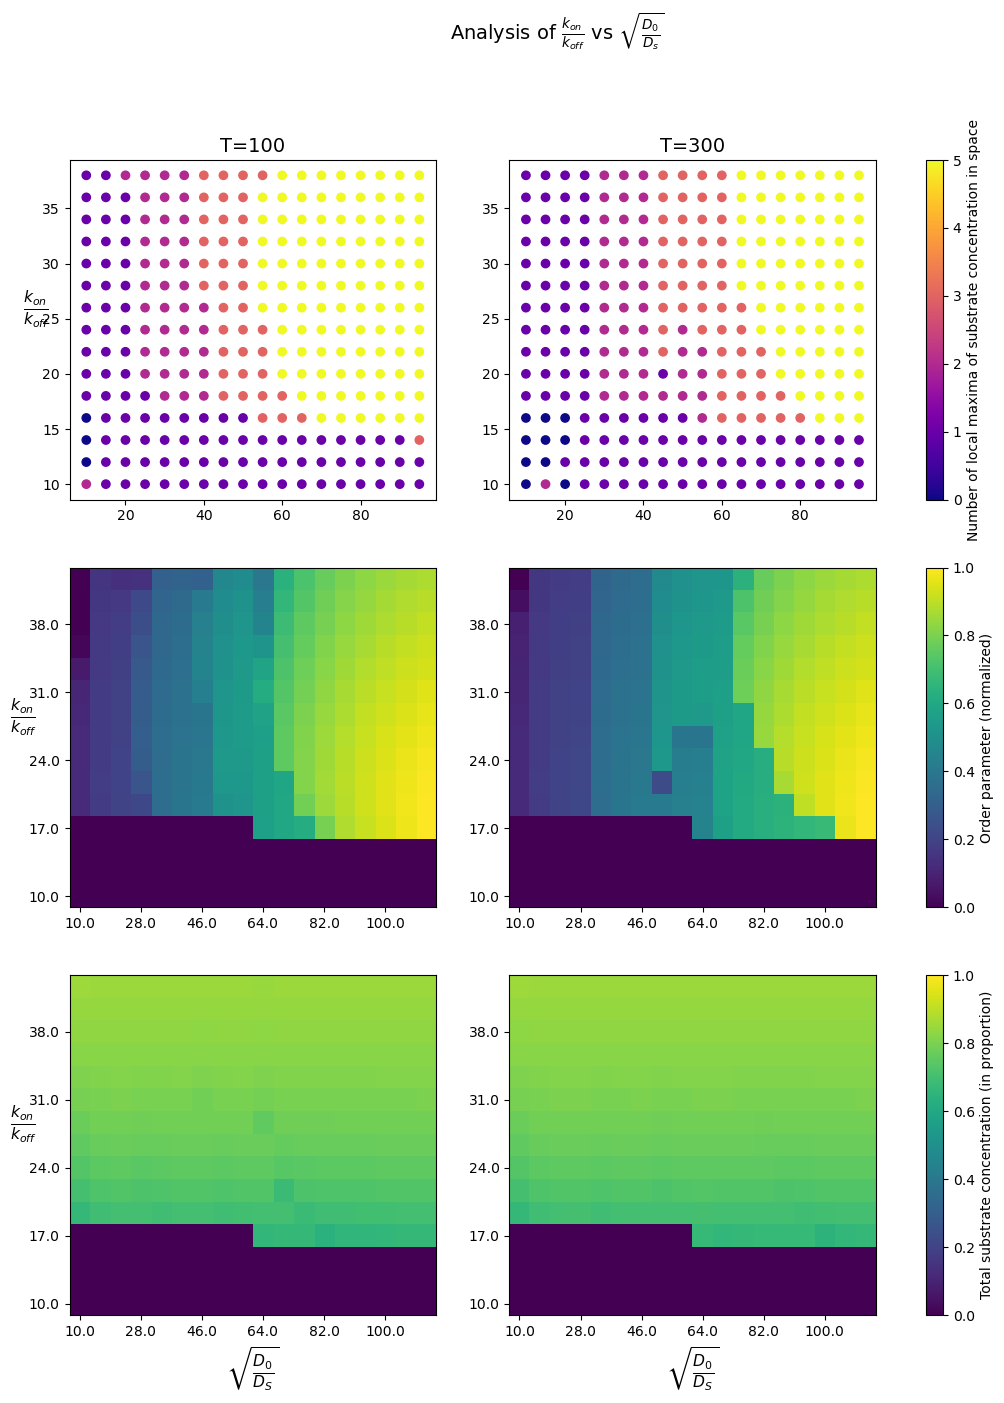

In [16]:
# D_ratio for T=100 and 300
kpeaks100, kS100, korder100 = load_results("k_ratio_vs_Dk_T100")
kpeaks300, kS300, korder300 = load_results("k_ratio_vs_Dk_T300")
k_ratio = np.arange(10, 40, 2) # kon/koff
plot_data(kpeaks100, 
          kS100, 
          korder100, 
          kpeaks300, 
          kS300, 
          korder300, 
          D_ratio=k_ratio,
          ylabel=r"$\frac{k_{on}}{k_{off}}$")

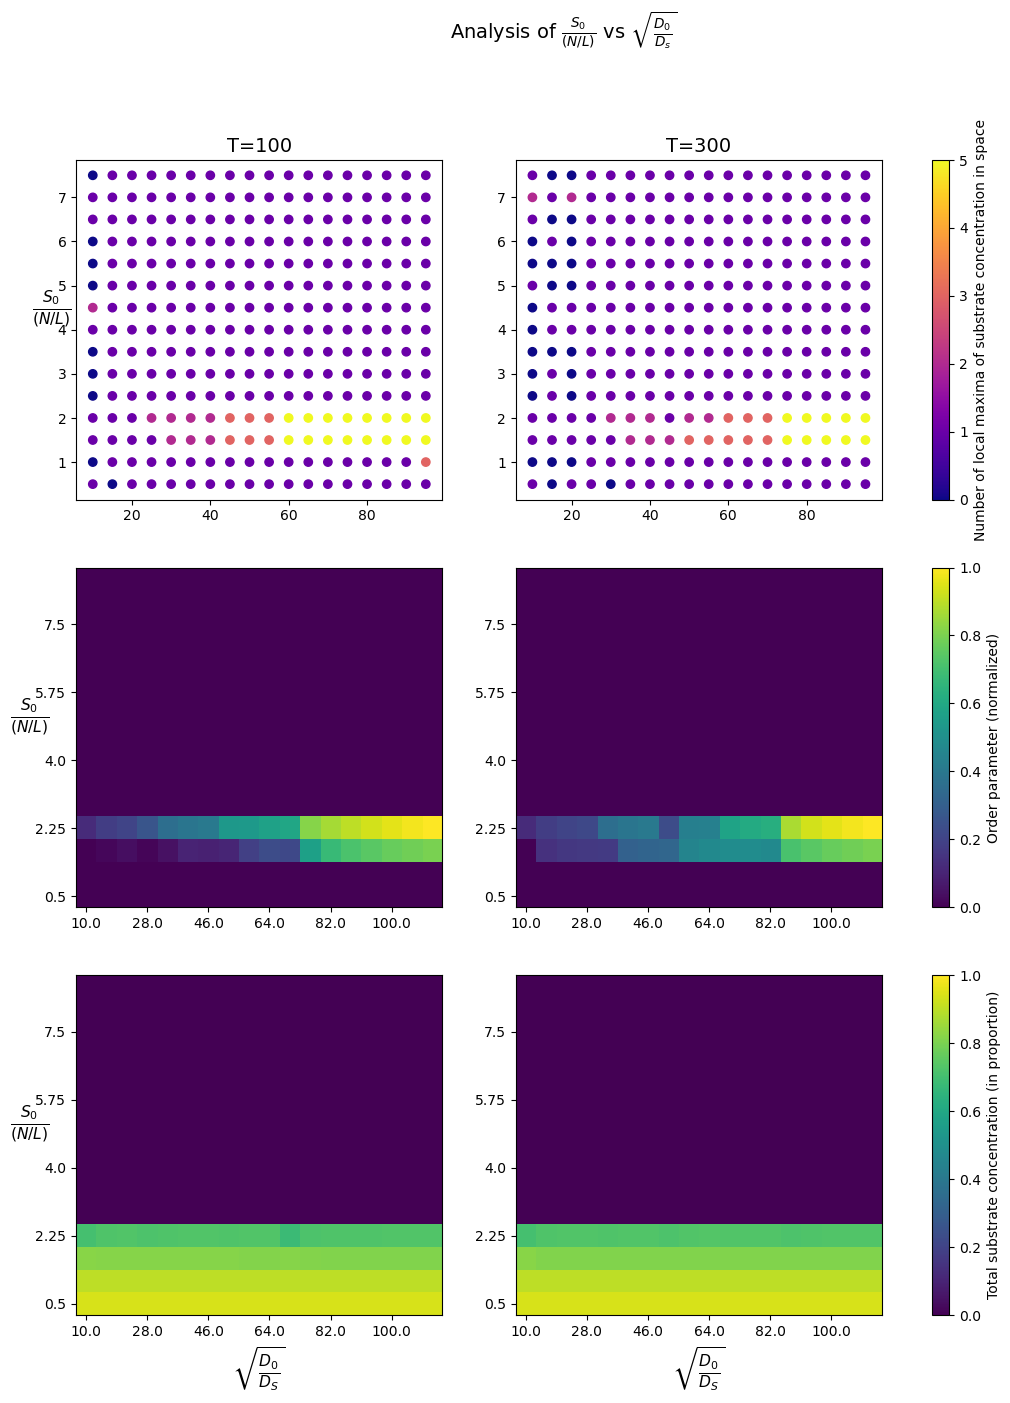

In [17]:
# conc to S0 ratio for T=100 and 300
cS0peaks100, cS0S100, cS0order100 = load_results("S0_to_conc_vs_Dk_T100")
cS0peaks300, cS0S300, cS0order300 = load_results("S0_to_conc_vs_Dk_T300")
cS0order100[0,:] = 0 # when S0=0, nan values
cS0order300[0,:] = 0

S0_to_conc = np.arange(0.5, 8.0, 0.5) # S0/(N/L)
plot_data(cS0peaks100, 
          cS0S100, # change this
          cS0order100, 
          cS0peaks300, 
          cS0S300, # change this
          cS0order300,
          D_ratio=S0_to_conc,
          ylabel=r"$\frac{S_0}{(N/L)}$")

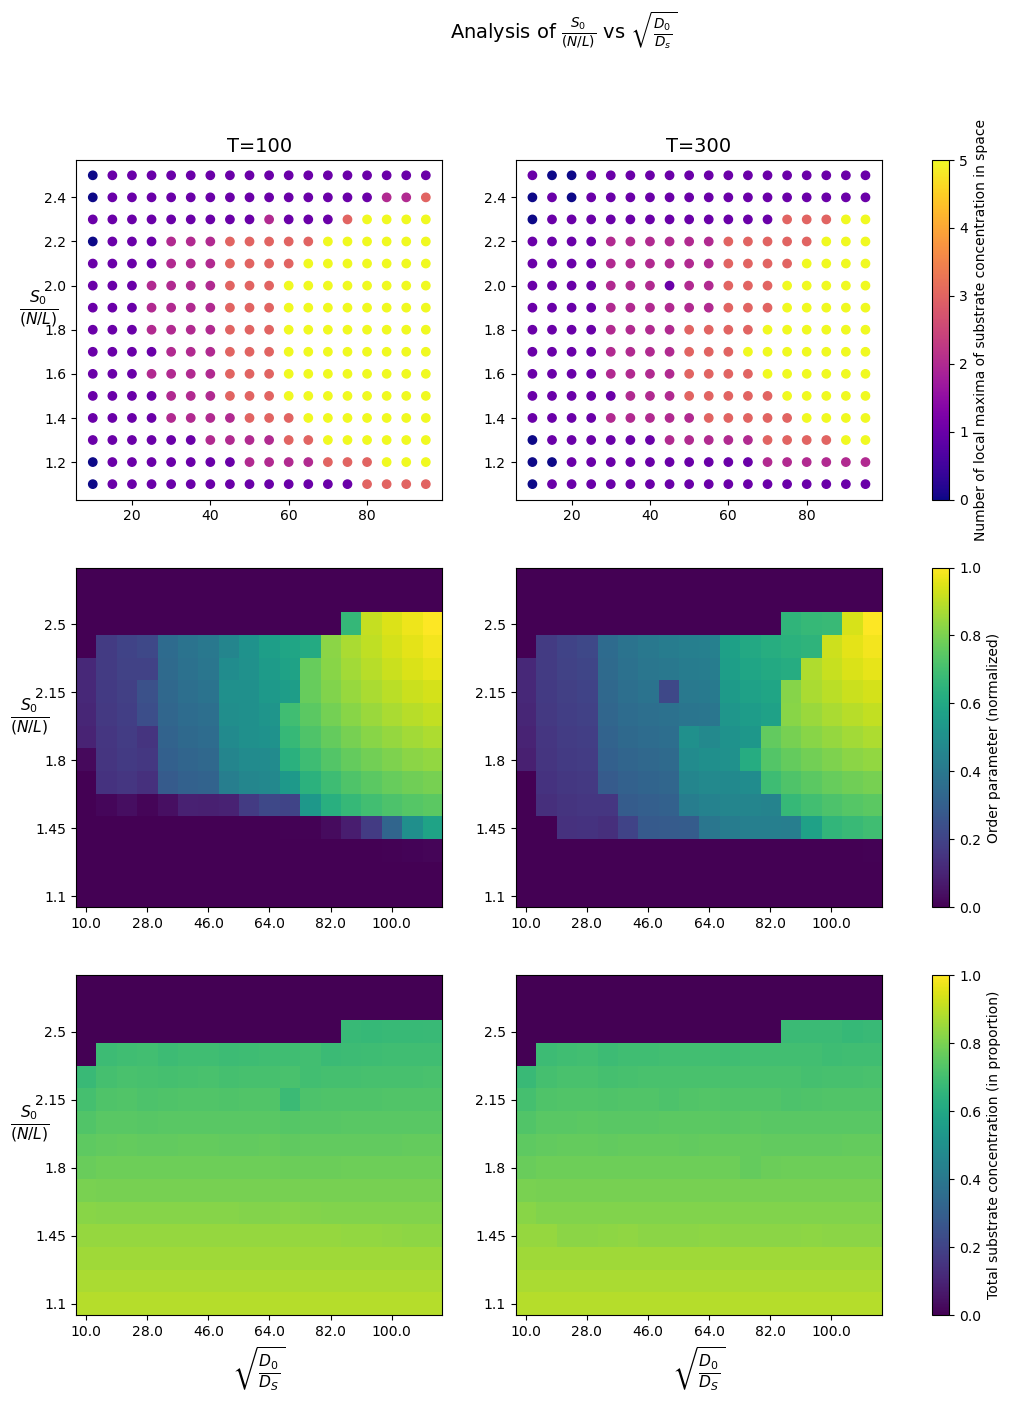

In [18]:
# Zoomed in conc to S0 ratio for T=100 and 300
cS0peaks100, cS0S100, cS0order100 = load_results("S0_to_conc_zoom_vs_Dk_T100")
cS0peaks300, cS0S300, cS0order300 = load_results("S0_to_conc_zoom_vs_Dk_T300")

S0_to_conc = np.arange(1.1, 2.6, 0.1) # S0/(N/L)
plot_data(cS0peaks100, 
          cS0S100, # change this
          cS0order100, 
          cS0peaks300, 
          cS0S300, # change this
          cS0order300,
          D_ratio=S0_to_conc,
          ylabel=r"$\frac{S_0}{(N/L)}$")

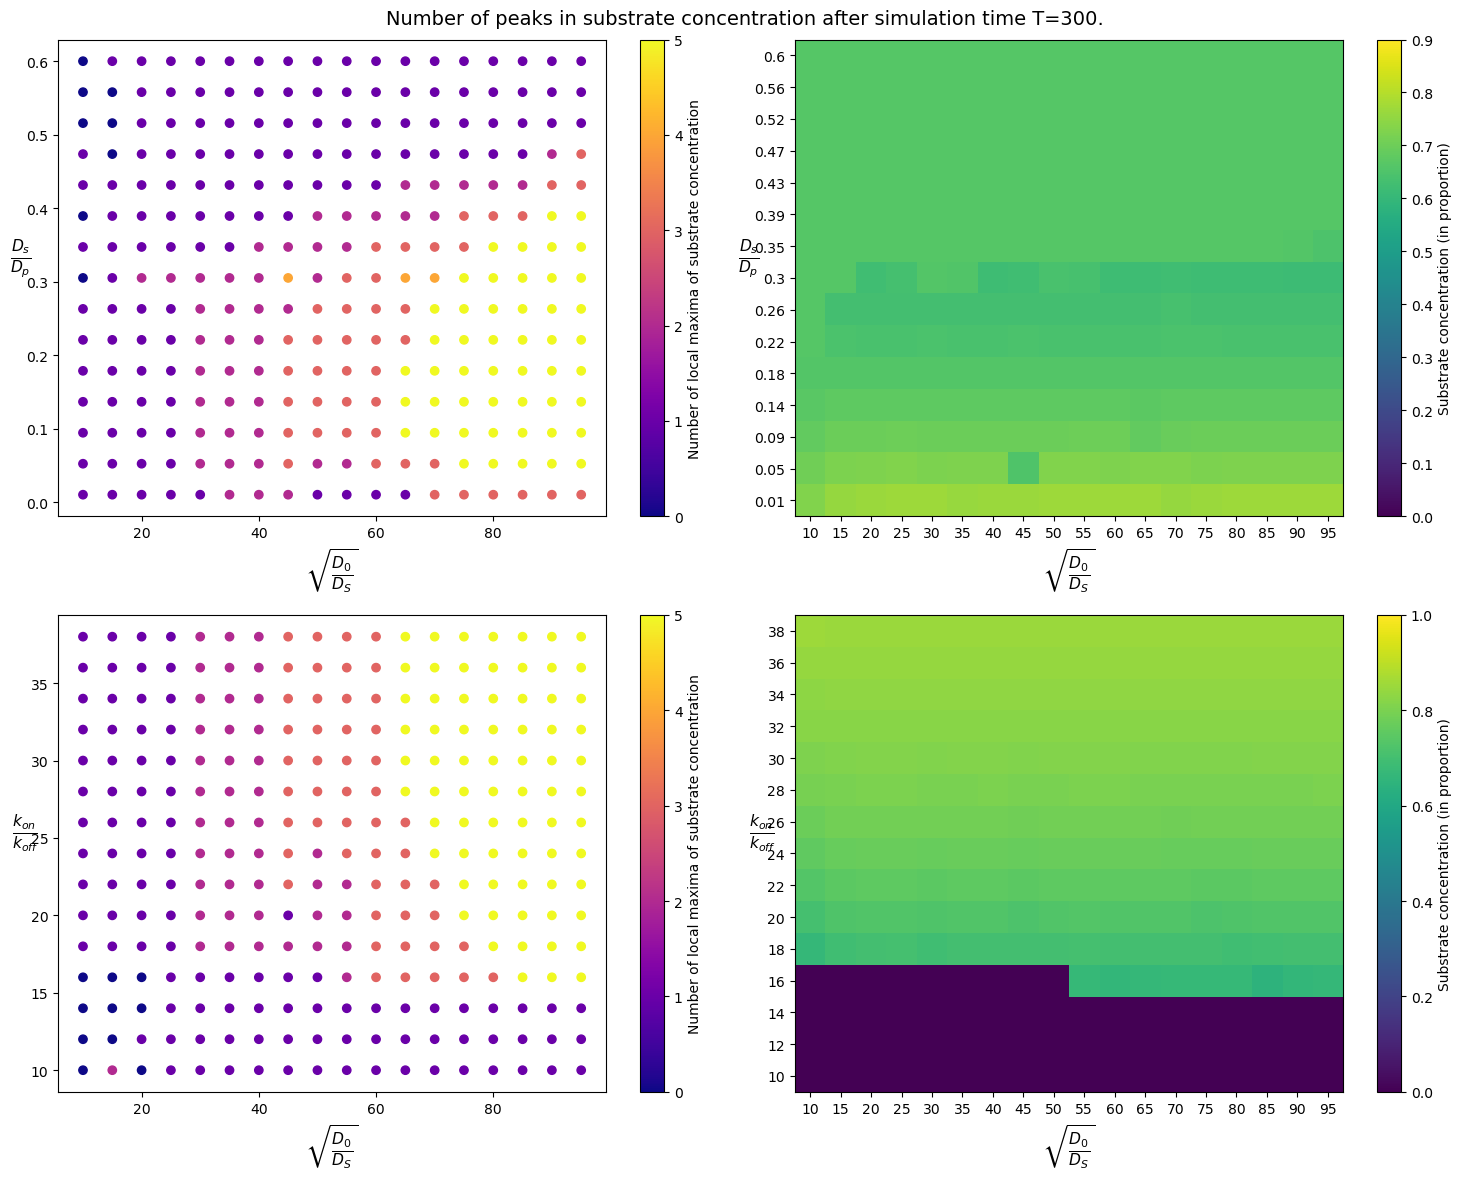

In [79]:
# D and k ratio in one plot
T = 300
D_ratio_results, D_ratio_Sconc, D_ratio_order = load_results("D_ratio_wider_vs_Dk_T300")
k_ratio_results, k_ratio_Sconc, k_ratio_order = load_results("k_ratio_vs_Dk_T300")

Dk = np.arange(10, 100, 5) # sqrt(D0/DS)
# D_ratio = np.linspace(0.01, 0.1, 10)
D_ratio = np.linspace(0.01, 0.6, 15) # wider Ds/Dp
k_ratio = np.arange(10, 40, 2)

row = 2
col = 2
fig, ax = plt.subplots(row, col, figsize=(15, 12))
fig.suptitle(f"Number of peaks in substrate concentration after simulation time T={T}.", fontsize=14)

for i in range(len(Dk)):
    im1 = ax[0][0].scatter(np.ones_like(D_ratio)*Dk[i], 
                           D_ratio, 
                           c=D_ratio_results[:, i], 
                           cmap="plasma", 
                           vmin=0, 
                           vmax=5)
    im2 = ax[1][0].scatter(np.ones_like(k_ratio)*Dk[i], 
                           k_ratio, 
                           c=k_ratio_results[:, i], 
                           cmap="plasma", 
                           vmin=0, 
                           vmax=5)

for i in range(col):
    ax[0][i].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
    ax[0][i].set_ylabel(r"$\frac{D_s}{D_p}$", fontsize=16, rotation=0)
    ax[1][i].set_xlabel(r"$\sqrt{\frac{D_0}{D_S}}$", fontsize=16)
    ax[1][i].set_ylabel(r"$\frac{k_{on}}{k_{off}}$", fontsize=16, rotation=0)
fig.colorbar(im1, label="Number of local maxima of substrate concentration")
fig.colorbar(im2, label="Number of local maxima of substrate concentration")

tickx = np.arange(0, len(Dk), 1)
ticky = np.arange(0, len(D_ratio), 1)

im3 = ax[0][1].imshow(D_ratio_Sconc, 
                      origin="lower", 
                      vmin=0, 
                      vmax=0.9,
                      aspect='auto')
ax[0][1].set_xticks(tickx)
ax[0][1].set_xticklabels(Dk.tolist())
ax[0][1].set_yticks(ticky)
ax[0][1].set_yticklabels(np.around(D_ratio, 2).tolist())
fig.colorbar(im3, label="Substrate concentration (in proportion)")

ticky = np.arange(0, len(k_ratio), 1)
im4 = ax[1][1].imshow(k_ratio_Sconc, 
                      origin="lower", 
                      vmin=0, 
                      vmax=1,
                      aspect='auto')
ax[1][1].set_xticks(tickx)
ax[1][1].set_xticklabels(Dk.tolist())
ax[1][1].set_yticks(ticky)
ax[1][1].set_yticklabels(np.around(k_ratio, 2).tolist())
fig.colorbar(im4, label="Substrate concentration (in proportion)")
plt.tight_layout()


By linear stability analysis of the system with no diffusion, the system is attaracted to line of equilibria if:
$$
p_{\infty}f'(s_{\infty}) - f(s_{\infty}) < 1/k
$$

same as

$$
\frac{1}{S_0}(\frac{N}{L} - S)f_{S_0}'(S) - f_{S_0}(S) < \frac{k_{off}}{k_{on}}
$$

note that $P = S_0p$, $S = S_0s$, $k=k_{on}/k_{off}$ and $P+S = N/L$, the total concentration.

The plot shows that in this parameter regime, the system always attracted to the line of equilibria.

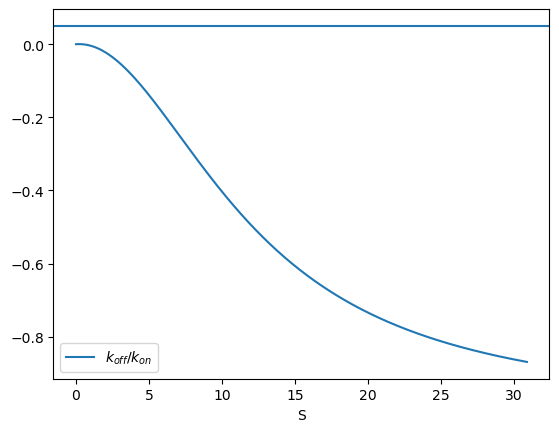

In [37]:
# plot profile
conc = 6
L = 5
N = conc*L
S0 = 2*conc
k_ratio = 20
def hill_function_derivative(s, n, s0):
    return (s0*n*s**(n-1))/((s0**n) + (s**n))**2

S = np.arange(0, N+1, 0.1)
condition = (1/S0)*(N-S)*hill_function_derivative(S, n=2, s0=S0) - sd.f(S, n=2, S0=S0)
plt.plot(S, condition)
plt.axhline(1/k_ratio, label=r"$k_{off}/k_{on}$")
plt.xlabel("S")
plt.legend()

In [ ]:
# # simulation params
# L = 10
# dx = 0.05
# x = np.arange(0, L+dx, dx)

# dt = 0.1
# T = 100
# tsteps = int(T/dt)

# # set parameters
# k_ratio = 20 # k_on/k_off
# k_off = 1 # TIME SCALE
# k_on = k_ratio * k_off

# # CONCENTRATION SCALE
# average_conc = 3
# N = average_conc*L 
# S0 = 2*average_conc # np.sqrt(10)

# # initial conditions
# Si = u.sinusoidal_perturbations(x, N, waves=5)
# Pi = np.zeros_like(x)

In [ ]:
# # visualize f sigmoid function 
# S = np.arange(0, 10, 0.05)
# plt.figure(figsize=(4,3))
# plt.ylabel("f(S)")
# plt.xlabel("Substrate Concentration, S")
# plt.axvline(S0, label="S0={S0}", color="Red")
# plt.plot(S, sd.f(S, n=2, S0=S0))

# visualize initial conditions
# plt.figure(figsize=(4,3))
# plt.title("Initial conditions")
# # plt.plot(x, Shom, label="Homogeneous Substrate concentration")
# plt.plot(x, Si, label="Initial Substrate concentration")
# plt.plot(x, Pi, label="Initial Pool concentration")
# plt.legend(fontsize=8)

In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(12,4))
# S_final = round(np.sum(St[:,-1]*dx), 2)
# P_final = round(np.sum(Pt[:,-1]*dx), 2)
# ax[0].set_title(f"Substrate concentration, final total={S_final}")
# ax[1].set_title(f"Pool concentration, final total={P_final}")
# time = np.arange(0, T+dt, dt)
# for t in range(tsteps+1):
#     if time[t]%100==0:
#         ax[0].plot(x, St[:, t], label=f"t={time[t]}")
#         ax[1].plot(x, Pt[:, t], label=f"t={time[t]}")
# ax[0].legend()
# ax[1].legend()